<a href="https://colab.research.google.com/github/data4class/Teaching/blob/main/Benford.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import yfinance as yf # Bonus Ex: Using NSE/BSE data
import pandas as pd

# Define the ticker symbol for any Stock
ticker_symbol = "INFY.NS" # Ex1: Generalize it for multiple symbols (nifty 500).

# Fetch the data
stock = yf.Ticker(ticker_symbol)

# Download balance sheet data for the last 40 quarters
balance_sheets = []
q = 40 # Ex2: Generalize it for all quarters
for i in range(1, (q+1)):
    quarter_data = stock.quarterly_balance_sheet
    quarter_data['Quarter'] = f'Q{i}'
    balance_sheets.append(quarter_data)
    stock.history(period='3mo', interval='1d')

# Combine the data into a single DataFrame
balance_sheet_data = pd.concat(balance_sheets)
print(balance_sheet_data)
# Save the data to a CSV file
#balance_sheet_data.to_csv(f'{ticker_symbol}_balance_sheet_last_{q}_quarters.csv')

print(f"Balance sheet data downloaded and saved to {ticker_symbol}_balance_sheet_last_10_quarters.csv'")


                                                  2025-06-30 00:00:00  \
Treasury Shares Number                                   9.098409e+06   
Ordinary Shares Number                                   4.145174e+09   
Share Issued                                             4.154273e+09   
Total Debt                                               6.930000e+08   
Tangible Book Value                                      9.403000e+09   
...                                                               ...   
Cash Cash Equivalents And Short Term Investments         4.089000e+09   
Other Short Term Investments                             8.870000e+08   
Cash And Cash Equivalents                                3.202000e+09   
Cash Equivalents                                                  NaN   
Cash Financial                                                    NaN   

                                                  2025-03-31 00:00:00  \
Treasury Shares Number                            

/tmp/ipython-input-3288032412.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  first_digits = balance_sheet_data[numerical_columns].applymap(get_first_digit).stack().dropna()


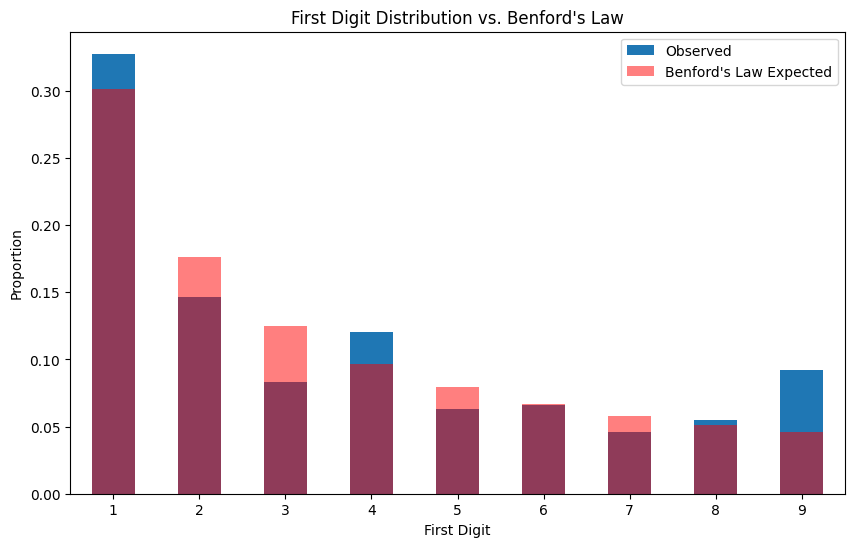

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Function to extract the first digit
def get_first_digit(num):
    if isinstance(num, (int, float)) and not pd.isna(num) and num != 0:
        return int(str(abs(num))[0])
    return None

# Apply the function to all numerical columns in the DataFrame
numerical_columns = balance_sheet_data.select_dtypes(include=np.number).columns
first_digits = balance_sheet_data[numerical_columns].applymap(get_first_digit).stack().dropna()

# Count the frequency of each first digit
digit_counts = first_digits.value_counts().sort_index()
total_digits = digit_counts.sum()
observed_proportions = digit_counts / total_digits

# Benford's Law expected proportions
expected_proportions = pd.Series([np.log10(1 + 1/d) for d in range(1, 10)], index=range(1, 10))

# Ex3: Generalize above for second, third, forth digit benford law

# Plot the observed vs. expected proportions
plt.figure(figsize=(10, 6))
observed_proportions.plot(kind='bar', label='Observed')
expected_proportions.plot(kind='bar', color='red', alpha=0.5, label="Benford's Law Expected")
plt.title("First Digit Distribution vs. Benford's Law")
plt.xlabel("First Digit")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend()
plt.show()


$P[d] = \log_{10}(1+ \frac{1}{d})$


# Chi-square
$\chi^2 = \sum_i {\frac{(o_i - e_i)^2}{e_i}}$

In [ ]:

# Chi-square test
# Calculate expected counts
expected_counts = expected_proportions * total_digits

# Ensure both series have the same index
observed_counts_aligned, expected_counts_aligned = digit_counts.align(expected_counts, fill_value=0)

# Calculate the chi-square statistic
chi2_statistic = ((observed_counts_aligned - expected_counts_aligned)**2 / expected_counts_aligned).sum()

# Degrees of freedom (number of categories - 1)
df = len(digit_counts) - 1

# P-value
p_value = 1 - chi2.cdf(chi2_statistic, df)

print(f"Chi-square statistic: {chi2_statistic:.4f}")
print(f"Degrees of freedom: {df}")
print(f"P-value: {p_value:.4f}")

# Interpret the result
alpha = 0.05
if p_value < alpha:
    print("The data distribution is significantly different from Benford's Law (reject the null hypothesis).")
else:
    print("The data distribution is not significantly different from Benford's Law (fail to reject the null hypothesis).")

Benford Law for second, third and forth digits

Benford's Law formulas for the second, third, and fourth digits:

**Second Digit:**
$P(d) = \sum_{k=1}^{9} \log_{10} \left(1 + \frac{1}{10k + d}\right)$ for $d \in \{0, 1, \dots, 9\}$

**Third Digit:**
$P(d) = \sum_{k=10}^{99} \log_{10} \left(1 + \frac{1}{100k + d}\right)$ for $d \in \{0, 1, \dots, 9\}$

**Fourth Digit:**
$P(d) = \sum_{k=100}^{999} \log_{10} \left(1 + \frac{1}{1000k + d}\right)$ for $d \in \{0, 1, \dots, 9\}$